C:\Anaconda\Lib\site-packages\optuna\_experimental.py:32: ExperimentalWarning: Argument ``multivariate`` is an experimental feature. The interface can change in the future.
  warnings.warn(
C:\Anaconda\Lib\site-packages\optuna\_experimental.py:32: ExperimentalWarning: Argument ``group`` is an experimental feature. The interface can change in the future.
  warnings.warn(
[I 2025-08-17 18:05:51,807] A new study created in memory with name: no-name-c9fb152d-a519-49cf-8291-3ba9057730fe


🔍 Trying seed 2635...

✅ Suitable seed found: 2635
Feedback sequence: [0, 2, 1, 2, 0, 1, 2, 1, 0, 0]

📋 Active modules per trial:
Trial 1: 3 active modules → ['distance/tim...', 'reason for t...', 'future turn ...']
Hue: 0.121, RGB: (255, 184, 0)


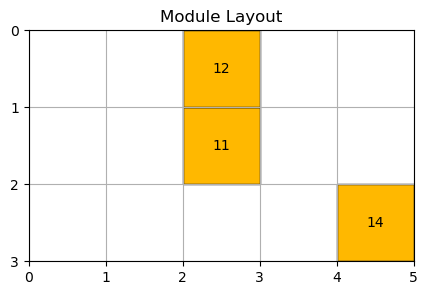

Trial 2: 3 active modules → ['Exit directi...', 'Obstacles at...', 'distance/tim...']
Hue: 0.010, RGB: (255, 15, 0)


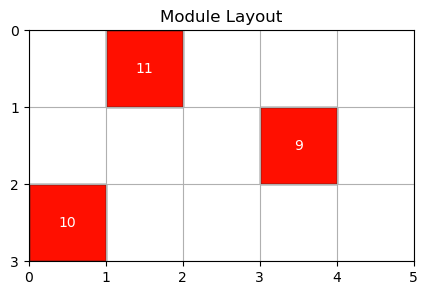

Trial 3: 3 active modules → ['Orientation ...', 'Exit directi...', 'reason for t...']
Hue: 0.275, RGB: (88, 255, 0)


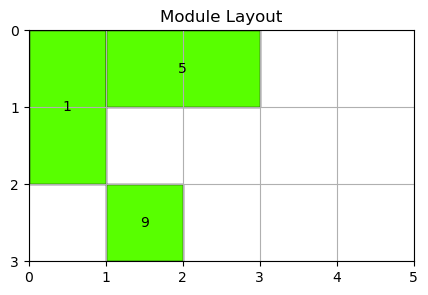

Trial 4: 4 active modules → ['Orientation ...', 'Exit directi...', 'distance/tim...', 'future turn ...']
Hue: 0.156, RGB: (255, 237, 0)


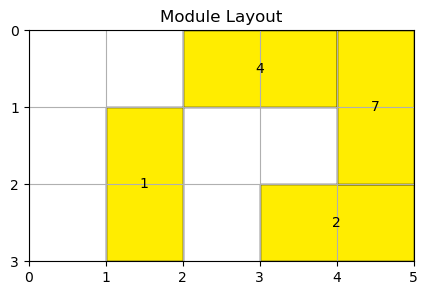

Trial 5: 6 active modules → ['Orientation ...', 'Exit directi...', 'Obstacles at...', 'reason for t...', 'other traffi...', 'future turn ...']
Hue: 0.435, RGB: (0, 255, 155)


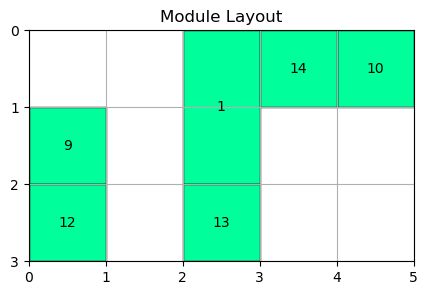

Trial 6: 4 active modules → ['Exit directi...', 'Obstacles at...', 'reason for t...', 'other traffi...']
Hue: 0.151, RGB: (255, 231, 0)


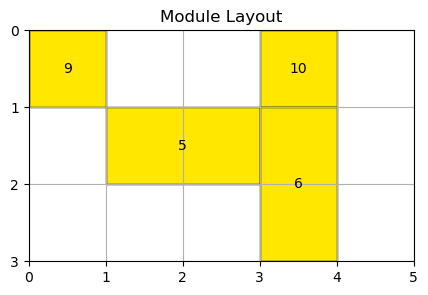

Trial 7: 4 active modules → ['Orientation ...', 'reason for t...', 'other traffi...', 'future turn ...']
Hue: 0.302, RGB: (48, 255, 0)


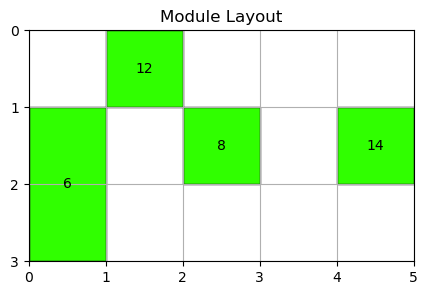

Trial 8: 4 active modules → ['Obstacles at...', 'distance/tim...', 'reason for t...', 'future turn ...']
Hue: 0.979, RGB: (255, 0, 32)


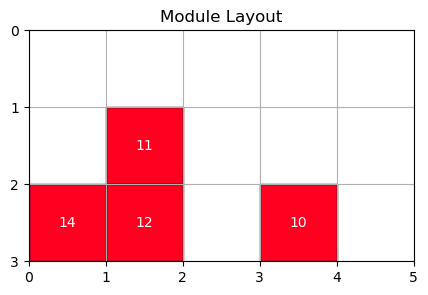

Trial 9: 4 active modules → ['Orientation ...', 'Exit directi...', 'Obstacles at...', 'other traffi...']
Hue: 0.638, RGB: (0, 43, 255)


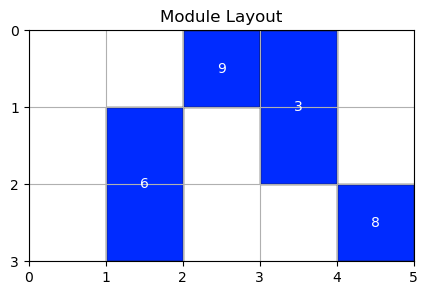

Trial 10: 3 active modules → ['distance/tim...', 'other traffi...', 'future turn ...']
Hue: 0.804, RGB: (210, 0, 255)


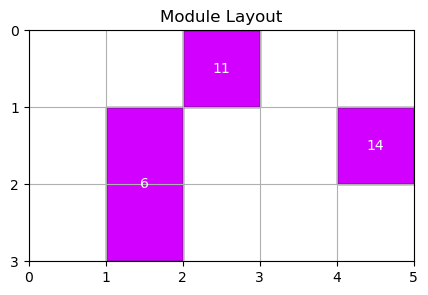

🎯 Use this seed in your main(): 2635


In [1]:
import optuna
from optuna.trial import TrialState
from optuna.samplers import TPESampler
import matplotlib.pyplot as plt
import numpy as np
import csv
import json
import os
from datetime import datetime
import time
import traceback
from optuna.trial import Trial
import random
import colorsys


BOARD_WIDTH = 5
BOARD_HEIGHT = 3
NUM_OBJECTS = 7
NUM_EVALS = 10

CSV_FILE = "trial_log.csv"

MODULE_NAMES = [
    "Orientation at Destination",
    "Exit direction & Ground condition at Exit",
    "Obstacles at Exit",
    "distance/time and relationship to the destination",
    "reason for the vehicle stopping",
    "other traffic members",
    "future turn & Upcoming maneuvers"
]

MODULE_ORIENTATIONS = [
    "vertical", "horizontal", "vertical",
    "horizontal", "horizontal", "vertical", "vertical"
]

SHAPES = ["Circle", "Triangle", "Square", "Hexagon", "Arrow"]

FEEDBACK_MAP = {
    0: "MX Black",
    1: "MX Grey",
    2: "MX Green"
}

def check_tpe_switch(trial):
    sampler = trial.study.sampler
    if not isinstance(sampler, TPESampler):
        print(f"Trial {trial.number}: Sampler is not TPESampler (it's {type(sampler)})")
        return

    # Count trials with COMPLETE or PRUNED state
    relevant_states = (TrialState.COMPLETE, TrialState.PRUNED)
    trials = trial.study._get_trials(deepcopy=False, states=relevant_states)

    num_trials = len(trials)
    n_startup = sampler._n_startup_trials  # the configured number of startup trials
    is_startup = True

    if num_trials < n_startup:
        #print(f"[Trial {trial.number}] Random sampling (startup phase) — {num_trials}/{n_startup} trials done")
        is_startup = True
    else:
        #print(f"[Trial {trial.number}] TPE sampling (after startup) — {num_trials}/{n_startup} trials done")
        is_startup = False

    return is_startup


def hue_to_rgb(hue):
    r, g, b = colorsys.hsv_to_rgb(hue, 1.0, 1.0)
    return int(r * 255), int(g * 255), int(b * 255)

def generate_layout(trial):
    #Test: Check when Optuna switches from Random to TPE
    is_startup = check_tpe_switch(trial)

    #
    used_positions = set()
    positions, sizes, colors, names = [], [], [], []
    shapes, use_rotations, use_vibrations = [], [], []
    is_pruned = False
    give_bad_score = False
    
    # Global parameters
    # Colour as HSV value with Saturation = 1 and Brightness (Value) = 1
    hue = trial.suggest_float("hue", 0, 1.0)
    r,g,b = hue_to_rgb(hue) # later code works with r,g,b values 
    feedback = trial.suggest_int("feedback", 0, 2)
    vibration_intensity = trial.suggest_int("vibration_intensity", 65, 100)
    vibration_on_time = trial.suggest_int("vibration_on_time", 5, 200)
    vibration_off_time = trial.suggest_int("vibration_off_time", 10, 500)
    extension_length = 8.5  # fixed value
    servo_speed = trial.suggest_int("servo_speed", 100, 300)
    sound_output_speed = trial.suggest_int("sound_output_speed", 100, 250)

    # Local parameters
    for i in range(NUM_OBJECTS):
        use_module = trial.suggest_categorical(f"use_module_{i}", [True, False])
        if not use_module:
            positions.append((None, None))
            sizes.append(None)
            colors.append(None)
            names.append(MODULE_NAMES[i])
            shapes.append(None)
            use_rotations.append(None)
            continue

        x = trial.suggest_int(f"x_{i}", 0, BOARD_WIDTH - 1)
        y = trial.suggest_int(f"y_{i}", 0, BOARD_HEIGHT - 1)
        is_large = trial.suggest_categorical(f"large_{i}", [True, False])
        orientation = MODULE_ORIENTATIONS[i]

        occupied = [(x, y)]
        if is_large:
            if orientation == "horizontal":
                if x + 1 >= BOARD_WIDTH:
                    if(is_startup):
                        raise optuna.TrialPruned()
                    else:
                        give_bad_score = True
                occupied.append((x + 1, y))
            else:
                if y + 1 >= BOARD_HEIGHT:
                    if(is_startup):
                        raise optuna.TrialPruned()
                    else:
                        give_bad_score = True
                occupied.append((x, y + 1))

        if any(pos in used_positions for pos in occupied):
            if(is_startup):
                raise optuna.TrialPruned()
            else:
                give_bad_score = True

        used_positions.update(occupied)
        positions.append((x, y))
        sizes.append((is_large, orientation))
        names.append(MODULE_NAMES[i])

        colors.append((r / 255, g / 255, b / 255))

        shape = trial.suggest_categorical(f"shape_{i}", SHAPES)
        use_vibration = trial.suggest_categorical(f"use_vibration_{i}", [True, False])
        use_rotation = trial.suggest_categorical(f"use_rotation_{i}", [True, False])

        shapes.append(shape)
        use_rotations.append(use_rotation)
        use_vibrations.append(use_vibration)

    return (positions, sizes, colors, names,
            shapes, feedback, vibration_on_time, vibration_off_time,
            vibration_intensity, use_rotations, use_vibrations,
            extension_length, servo_speed, sound_output_speed, is_pruned, give_bad_score, hue)



def plot_board_with_shapes(positions, sizes, colors, names=None, board_size=(BOARD_WIDTH, BOARD_HEIGHT)):
    fig, ax = plt.subplots(figsize=(board_size[0], board_size[1]))
    ax.set_xlim(0, board_size[0])
    ax.set_ylim(0, board_size[1])
    ax.set_xticks(range(board_size[0] + 1))
    ax.set_yticks(range(board_size[1] + 1))
    ax.grid(True)
    ax.set_aspect('equal')
    ax.invert_yaxis()

    for i, ((x, y), size, color) in enumerate(zip(positions, sizes, colors)):
        if (x, y) is None or size is None or color is None:
            continue

        label_num = i + 1
        is_large, orientation = size
        if not is_large:
            label_num += 7
        label = str(label_num)

        cx, cy = x + 0.5, y + 0.5

        # Compute luminance to decide text color
        r, g, b = color
        luminance = 0.299 * r + 0.587 * g + 0.114 * b
        text_color = 'white' if luminance < 0.5 else 'black'

        if is_large:
            width = 2 if orientation == "horizontal" else 1
            height = 1 if orientation == "horizontal" else 2
            ax.add_patch(plt.Rectangle((x, y), width, height, color=color, ec='black'))
            ax.text(x + width / 2, y + height / 2, label, ha='center', va='center', fontsize=10, color=text_color)
        else:
            ax.add_patch(plt.Rectangle((x, y), 1, 1, color=color, ec='black'))
            ax.text(cx, cy, label, ha='center', va='center', fontsize=10, color=text_color)

    plt.title("Module Layout")
    plt.show()


import optuna
from optuna.samplers import TPESampler
from optuna.trial import TrialState
from collections import Counter
from IPython.display import clear_output


NUM_TRIALS = 10
MAX_SEED_TRIES = 10000  # Try up to 10000 different seeds
MODULE_COUNT = 7
OFFSET = 2635

def rebuild_layout_from_params(trial, params):
    used_positions = set()
    positions, sizes, colors, names = [], [], [], []

    hue = trial.params.get("hue", 0)
    r, g, b = hue_to_rgb(hue)

    # Print hue and 0-255 RGB
    print(f"Hue: {hue:.3f}, RGB: ({r}, {g}, {b})")
    
    r = float(r / 255)
    g = float(g / 255)
    b = float(b / 255)

    for i in range(NUM_OBJECTS):
        use_module = params.get(f"use_module_{i}", False)
        names.append(MODULE_NAMES[i])

        if not use_module:
            positions.append((None, None))
            sizes.append(None)
            colors.append(None)
            continue

        x = params.get(f"x_{i}", 0)
        y = params.get(f"y_{i}", 0)
        is_large = params.get(f"large_{i}", False)
        orientation = MODULE_ORIENTATIONS[i]

        positions.append((x, y))
        sizes.append((is_large, orientation))
        colors.append((r, g, b))

    return positions, sizes, colors, names


def is_feedback_sequence_valid(feedbacks):
    """
    Check if the feedback sequence contains exactly 3 consecutive blocks
    of 3–4 repeated feedback values, and all feedback values are different.
    Example valid patterns:
      - [0,0,0,1,1,1,2,2,2]
      - [2,2,2,2,0,0,0,1,1,1]
    """
    if len(feedbacks) != 10:
        return False

    blocks = []
    current = feedbacks[0]
    count = 1

    for fb in feedbacks[1:]:
        if fb == current:
            count += 1
        else:
            blocks.append((current, count))
            current = fb
            count = 1
    blocks.append((current, count))  # add last block

    # Check for 3 blocks only
    if len(blocks) != 3:
        return False

    # Check block sizes and distinct feedback values
    values = set()
    for val, length in blocks:
        if length < 3 or length > 4:
            return False
        values.add(val)

    return len(values) == 3


def has_sufficient_module_usage(trials):
    """
    Check if each use_module_i (for i=0..6) is True in at least 6 of the 10 trials.
    """
    counts = [0] * MODULE_COUNT
    for trial in trials:
        for i in range(MODULE_COUNT):
            if trial.params.get(f"use_module_{i}") is True:
                counts[i] += 1
    return all(count >= 5 for count in counts)

def test_seeds_for_valid_startup_trials():
    for seed in range(MAX_SEED_TRIES):
        seed=seed + OFFSET
        clear_output(wait=True)
        print(f"🔍 Trying seed {seed}...")
        sampler = TPESampler(n_startup_trials= 10, gamma=lambda n: int(0.4 * n), multivariate=True, group=True, seed=seed)

        study = optuna.create_study(
            directions=["maximize", "minimize"],
            sampler=sampler
        )

        feedbacks = []
        startup_trials = []
        attempts = 0

        while len(feedbacks) < NUM_TRIALS and attempts < 10000:
            trial = study.ask()
            attempts += 1
            try:
                generate_layout(trial)
                feedbacks.append(trial.params.get("feedback"))
                startup_trials.append(trial)
            except optuna.TrialPruned:
                #study.tell(trial, state=TrialState.PRUNED)
                continue  # skip and try again
            #except Exception as e:
             #   print(f"Error encountered: {type(e).__name__}: {e}")
              #  import traceback
               # traceback.print_exc()  # prints full stack trace
                #break  # stop the loop immediately

        if len(feedbacks) == NUM_TRIALS:
            if has_sufficient_module_usage(startup_trials):
                print(f"\n✅ Suitable seed found: {seed}")
                print(f"Feedback sequence: {feedbacks}")

                MAX_LEN = 15  # max length for each module name
                
                print("\n📋 Active modules per trial:")
                for idx, trial in enumerate(startup_trials):
                    used_modules = []
                    for i in range(MODULE_COUNT):
                        if trial.params.get(f"use_module_{i}") is True:
                            name = MODULE_NAMES[i]
                            if len(name) > MAX_LEN:
                                name = name[:MAX_LEN-3] + "..."
                            used_modules.append(name)
                    print(f"Trial {idx + 1}: {len(used_modules)} active modules → {used_modules}")

                    #Build and plot layout from saved params
                    positions, sizes, colors, names = rebuild_layout_from_params(trial, trial.params)
                    plot_board_with_shapes(positions, sizes, colors, names)

                return seed

    print("❌ No suitable seed found after", MAX_SEED_TRIES, "tries.")
    return None


if __name__ == "__main__":
    seed = test_seeds_for_valid_startup_trials()
    if seed is not None:
        print(f"🎯 Use this seed in your main(): {seed}")